In [1]:
from torch import nn
import kagglehub
import torch
from torch import Tensor
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchvision import datasets, transforms
import torchvision.models as models
from torch.optim import Adam, SGD
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader, random_split, ConcatDataset
import seaborn as sns
from PIL import Image
from pathlib import Path
from timeit import default_timer as timer
import cv2
import timm

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not Path('/home/var-roman/.cache/kagglehub/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images/versions/1/datasetcopy/traindataset/').exists():
    kagglehub.dataset_download('siddharthkumarsah/logo-dataset-2341-classes-and-167140-images')
dataset_path = '/home/var-roman/Desktop/For_studying/7_semester/PR_PZ/Lab6/dataset_mizuno/'

print("Path to dataset files:", dataset_path)
print('Device: ', device)

Path to dataset files: /home/var-roman/Desktop/For_studying/7_semester/PR_PZ/Lab6/dataset_mizuno/
Device:  cuda


In [3]:
IMG_SIZE = 299
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_CLASSES = 1

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

train_dataset = datasets.ImageFolder(root=dataset_path + 'train', transform=train_transform)
test_dataset = datasets.ImageFolder(root=dataset_path + 'test', transform=basic_transform)

# additional_train_dataset, augment_train_dataset = random_split(train_dataset, [len(train_dataset) // 2, len(train_dataset) // 2 + 1])
#
# augment_train_dataset.dataset.transform = train_transform
# train_dataset = ConcatDataset([train_dataset, augment_train_dataset])
train_dataset.classes = ['mizuno', 'negative']

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS,
                             pin_memory=True)

print(f"Дані завантажено. Класи: {train_dataset.classes}")

Дані завантажено. Класи: ['mizuno', 'negative']


In [4]:
class_names = train_dataset.classes
NUM_CLASSES = 1

print(f"Кількість класів: {NUM_CLASSES} (Бінарна класифікація)")
print(f"Імена класів: {class_names}")

Кількість класів: 1 (Бінарна класифікація)
Імена класів: ['mizuno', 'negative']


In [5]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer: torch.optim.Optimizer) -> float:

    loss_count: float = 0.0
    model.train()
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        output_logits = model(X)
        y = y.float().unsqueeze(1)
        loss = loss_fn(output_logits, y)
        loss_count += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_count /= len(data_loader)
    return loss_count


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    all_preds = []
    all_labels = []
    test_loss = 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            y_float = y.float().unsqueeze(1)
            test_loss += loss_fn(test_pred_logits, y_float).item()
            preds = torch.round(torch.sigmoid(test_pred_logits))

            all_preds.append(preds.cpu().flatten())
            all_labels.append(y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        test_loss /= len(data_loader)

        return test_loss, all_preds, all_labels


def save_model(model: torch.nn.Module, model_name: str):
    model_path = Path("models")
    model_path.mkdir(parents=True,
                     exist_ok=True)

    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name

    print(f"Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)

def load_model(model: torch.nn.Module, model_name: str) -> torch.nn.Module:
    model_path = Path("models")
    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name
    model.load_state_dict(torch.load(f=model_save_path,weights_only=True))
    model = model.to(device)
    return model

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

def calc_metrics(y_preds, y_true, epochs_train_lt, epochs_test_lt,
                 epochs_num, model_name, num_classes):
    acc_fn = Accuracy(task="binary")
    accuracy = acc_fn(y_preds, y_true)
    print(f"Загальна точність (Accuracy): {accuracy.item():.4f}")

    conf_matrix_fn = ConfusionMatrix(task="binary")
    prec_fn_macro = Precision(task="binary", average='macro')
    recall_fn_macro = Recall(task="binary", average='macro')
    f1_fn_macro = F1Score(task="binary", average='macro')

    conf_matrix = conf_matrix_fn(y_preds, y_true).numpy()
    precision_macro = prec_fn_macro(y_preds, y_true)
    recall_macro = recall_fn_macro(y_preds, y_true)
    f1_macro = f1_fn_macro(y_preds, y_true)

    print(f"Усереднена прецизійність (Macro Precision): {precision_macro.item():.4f}")
    print(f"Усереднена повнота (Macro Recall): {recall_macro.item():.4f}")
    print(f"Усереднений F1-Score (Macro F1-Score): {f1_macro.item():.4f}")

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax = ax[0]
    )
    ax[0].set_xlabel('Передбачений клас (Predicted Label)')
    ax[0].set_ylabel('Справжній клас (True Label)')
    ax[0].set_title('Матриця помилок (Confusion Matrix)')

    ax[1].plot(range(epochs_num), epochs_train_lt, label="Train loss")
    ax[1].plot(range(epochs_num), epochs_test_lt, label="Test loss")
    ax[1].set_title(f"Модель: {model_name}")
    ax[1].set_ylabel("Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

In [6]:
def print_train_time(start, end):
        total_time = end - start
        print(f"Загальний час тренування на {device}: {total_time:.3f} секунд")
        return total_time

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,
            bias=bias)

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=bias
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.skip_connection = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels))

        self.main_path = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            SeparableConv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.MaxPool2d(kernel_size=3, stride=stride, padding=1))

    def forward(self, x):
        skip = self.skip_connection(x)
        main = self.main_path(x)
        return skip + main

class MiddleFlowBlock(nn.Module):
    def __init__(self, channels=728):
        super().__init__()

        self.main_path = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.main_path(x)

class Xception(nn.Module):
    def __init__(self, num_classes=10, ):
        super().__init__()

        self.entry_flow = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 728, stride=2))

        middle_flow_blocks = []
        for _ in range(8):
            middle_flow_blocks.append(MiddleFlowBlock(728))
        self.middle_flow = nn.Sequential(*middle_flow_blocks)

        self.exit_flow = nn.Sequential(
            ResidualBlock(728, 1024, stride=2),
            SeparableConv2d(1024, 1536, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1536),
            nn.ReLU(inplace=True),

            SeparableConv2d(1536, 2048, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True))

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.entry_flow(x)
        x = self.middle_flow(x)
        x = self.exit_flow(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


    # def _initialize_weights(self):
    #     for m in self.modules():
    #         if isinstance(m, (nn.Conv2d, nn.Linear)):
    #             if hasattr(m, 'stddev'):
    #                 nn.init.trunc_normal_(m.weight, mean=0.0, std=m.stddev, a=-2.0, b=2.0)
    #                 if m.bias is not None:
    #                     nn.init.constant_(m.bias, 0)
    #             else:
    #                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    #
    #         elif isinstance(m, nn.BatchNorm2d):
    #             nn.init.constant_(m.weight, 1)
    #             nn.init.constant_(m.bias, 0)

In [10]:
temp_model = timm.create_model('xception', pretrained=True)
pretrained_weights = temp_model.state_dict()

model = Xception(num_classes=NUM_CLASSES)
model.to(device)

keys_to_remove = ['fc.weight', 'fc.bias']
for key in keys_to_remove:
    if key in pretrained_weights:
        pretrained_weights.pop(key)
        print(f"Removed key: {key}")

print("\nLoading pre-trained weights into custom Xception...")
model.load_state_dict(pretrained_weights, strict=False)
print("Weights loaded successfully!")

for param in model.parameters():
    param.requires_grad = False

print("\nUnfreezing layers for training:")

layers_to_unfreeze = [
    model.fc,
    model.exit_flow,
    model.middle_flow, # for ..._v1... models
    # model.entry_flow
]

for layer in layers_to_unfreeze:
    if layer is not None:
        for param in layer.parameters():
            param.requires_grad = True
            print(f" - Unfreezing params in: {layer.__class__.__name__}")

params_to_train = [p.shape for p in model.parameters() if p.requires_grad]
print(f"\nParameters to be trained shapes: {params_to_train}")

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001)

criterion = nn.BCEWithLogitsLoss()

Removed key: fc.weight
Removed key: fc.bias

Loading pre-trained weights into custom Xception...
Weights loaded successfully!

Unfreezing layers for training:
 - Unfreezing params in: Linear
 - Unfreezing params in: Linear
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params 

In [11]:
def training_process(num_epoch: int,
                     model: torch.nn.Module,
                     optimizer: torch.optim.Optimizer,
                     loss_fn: torch.nn.Module,
                     train_loader: DataLoader,
                     test_loader: DataLoader):
    train_time_start_on_gpu = timer()

    epochs_train_lt_1 = []
    epochs_test_lt_1 = []

    epochs = num_epoch
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n---------")

        train_loss_value = training_step(data_loader=train_loader,
                                         model=model,
                                         loss_fn=loss_fn,
                                         optimizer=optimizer)
        epochs_train_lt_1.append(train_loss_value)
        test_loss_var_1, y_preds_1, y_true_1 = test_step(data_loader=test_loader,
                                                         model=model,
                                                         loss_fn=loss_fn)

        epochs_test_lt_1.append(test_loss_var_1)

        print(f"Train loss: {train_loss_value:.4f} | Test loss: {test_loss_var_1:.4f}")


    train_time_end_on_gpu = timer()


    total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                                end=train_time_end_on_gpu)

    return epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1

In [12]:
epochs_count = 10
epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1 = training_process(epochs_count, model, optimizer, criterion, train_dataloader, test_dataloader)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------


 10%|█         | 1/10 [07:16<1:05:28, 436.51s/it]

Train loss: 0.0439 | Test loss: 0.0478
Epoch: 1
---------


 20%|██        | 2/10 [14:34<58:19, 437.38s/it]  

...

Train loss: 0.0130 | Test loss: 0.0171
Epoch: 8
---------


 90%|█████████ | 9/10 [1:05:01<07:16, 436.39s/it]

Train loss: 0.0126 | Test loss: 0.0117
Epoch: 9
---------


100%|██████████| 10/10 [1:12:18<00:00, 433.86s/it]

Train loss: 0.0104 | Test loss: 0.0092
Загальний час тренування на cuda: 4338.584 секунд


Загальна точність (Accuracy): 0.9982
Усереднена прецизійність (Macro Precision): 0.9983
Усереднена повнота (Macro Recall): 0.9999
Усереднений F1-Score (Macro F1-Score): 0.9991


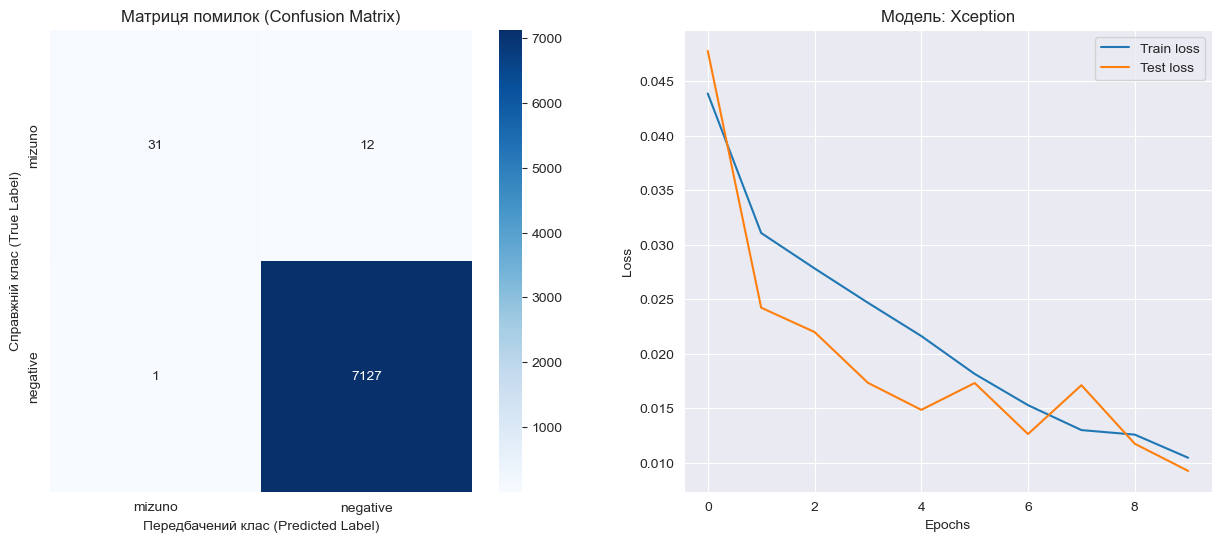

In [13]:
calc_metrics(y_preds=y_preds_1,
             y_true=y_true_1,
             epochs_train_lt=epochs_train_lt_1,
             epochs_test_lt=epochs_test_lt_1,
             epochs_num=epochs_count,
             model_name="Xception",
             num_classes=NUM_CLASSES)

In [14]:
save_model(model=model, model_name='Xception_v1_1')

Saving model to: models/Xception_v1_1.pth


In [16]:
model = load_model(model=model, model_name='Xception_v1_1')

## Video test

In [24]:
def process_video_sliding_window(video_path, model, transform, threshold, batch_size_patches=64):
    WINDOW_SIZE = 299
    STRIDE = 150

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Помилка відео: {video_path}")
        return [], [], 0

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Обробка відео (режим ковзного вікна): {frame_count} кадрів, FPS: {fps:.2f}")

    frame_indices = []
    frame_probs = []

    current_frame_idx = 0

    with torch.inference_mode():
        pbar = tqdm(total=frame_count, desc="Обробка кадрів")
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_h, frame_w, _ = frame.shape
            patches_for_this_frame = []

            for y in range(0, frame_h - WINDOW_SIZE + 1, STRIDE):
                for x in range(0, frame_w - WINDOW_SIZE + 1, STRIDE):
                    patch_bgr = frame[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
                    patch_rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
                    pil_img = Image.fromarray(patch_rgb)

                    img_tensor = transform(pil_img)
                    patches_for_this_frame.append(img_tensor)

            if not patches_for_this_frame:
                current_frame_idx += 1
                pbar.update(1)
                continue

            frame_min_prob = 1.0

            for i in range(0, len(patches_for_this_frame), batch_size_patches):
                batch_chunk = patches_for_this_frame[i:i + batch_size_patches]

                patch_batch_tensor = torch.stack(batch_chunk).to(device)

                logits = model(patch_batch_tensor)
                probs = torch.sigmoid(logits)

                min_prob_in_batch = probs.min().item()
                if min_prob_in_batch < frame_min_prob:
                    frame_min_prob = min_prob_in_batch

            frame_probs.append(frame_min_prob)
            frame_indices.append(current_frame_idx)

            current_frame_idx += 1
            pbar.update(1)

        pbar.close()

    cap.release()
    print("Пакетна обробка (ковзне вікно) завершена.")
    return frame_indices, frame_probs, fps

def post_process_and_report_timestamps(frame_indices, frame_probs, fps, threshold, smoothing_window=5):

    probs_np = np.array(frame_probs)
    print("\nЗвіт про виявлення (Сирі дані)")
    raw_predictions = (probs_np < threshold).astype(int)
    raw_indices = np.array(frame_indices)

    start_frame_raw = -1
    detected_periods_raw = []

    for i in range(len(raw_predictions)):
        frame_idx = raw_indices[i]

        # Початок нового проміжку
        if raw_predictions[i] == 1 and (i == 0 or raw_predictions[i-1] == 0):
            start_frame_raw = frame_idx

        # Кінець проміжку
        if raw_predictions[i] == 0 and i > 0 and raw_predictions[i-1] == 1:
            end_frame_raw = raw_indices[i-1]
            start_time = start_frame_raw / fps
            end_time = end_frame_raw / fps
            if end_time > start_time:
                 period = f"Логотип виявлено [Сирі]: з {start_time:.2f}s по {end_time:.2f}s"
                 print(period)
                 detected_periods_raw.append(period)
            start_frame_raw = -1

    if start_frame_raw != -1:
        end_frame_raw = raw_indices[-1]
        start_time = start_frame_raw / fps
        end_time = end_frame_raw / fps
        period = f"Логотип виявлено [Сирі]: з {start_time:.2f}s по {end_time:.2f}s"
        print(period)
        detected_periods_raw.append(period)

    if not detected_periods_raw:
        print("Логотип 'Mizuno' не виявлено [Сирі].")

    print("\nЗвіт про виявлення (після пост-обробки)")

    if smoothing_window > 1:
        kernel = np.ones(smoothing_window) / smoothing_window
        smoothed_probs = np.convolve(probs_np, kernel, mode='valid')
        offset = (smoothing_window - 1) // 2

        valid_len = len(smoothed_probs)
        smoothed_indices = frame_indices[offset : offset + valid_len]
    else:
        smoothed_probs = probs_np
        smoothed_indices = frame_indices

    predictions = (smoothed_probs < threshold).astype(int)

    start_frame = -1
    detected_periods_smooth = []

    for i in range(len(predictions)):
        frame_idx = smoothed_indices[i]

        if predictions[i] == 1 and (i == 0 or predictions[i-1] == 0):
            start_frame = frame_idx

        if predictions[i] == 0 and i > 0 and predictions[i-1] == 1:
            end_frame = smoothed_indices[i-1]
            start_time = start_frame / fps
            end_time = end_frame / fps
            if end_time > start_time:
                 period = f"Логотип виявлено [Згладжено]: з {start_time:.2f}s по {end_time:.2f}s"
                 print(period)
                 detected_periods_smooth.append(period)
            start_frame = -1

    if start_frame != -1:
        end_frame = smoothed_indices[-1]
        start_time = start_frame / fps
        end_time = end_frame / fps
        period = f"Логотип виявлено [Згладжено]: з {start_time:.2f}s по {end_time:.2f}s"
        print(period)
        detected_periods_smooth.append(period)

    if not detected_periods_smooth:
        print("Логотип 'Mizuno' не виявлено [Згладжено].")

    plt.figure(figsize=(15, 5))
    plt.plot(frame_indices, probs_np, label='Сирі ймовірності (min prob per frame)', alpha=0.4, color='blue')
    plt.plot(smoothed_indices, smoothed_probs, label=f'Згладжені (вікно={smoothing_window})', color='red')
    plt.axhline(threshold, color='black', linestyle=':', label=f'Поріг ({threshold})')
    plt.title('Порівняння сирих та згладжених передбачень')
    plt.xlabel('Кадр')
    plt.ylabel('Ймовірність логотипу (де < 0.5 = Mizuno)')
    plt.legend()
    plt.show()

Крок 1: Пакетна обробка (Ковзне вікно)
Обробка відео (режим ковзного вікна): 1955 кадрів, FPS: 23.98


Обробка кадрів: 100%|█████████▉| 1952/1955 [04:50<00:00,  6.71it/s]


Пакетна обробка (ковзне вікно) завершена.

Крок 2: Пост-обробка та виведення результатів

Звіт про виявлення (Сирі дані)
Логотип виявлено [Сирі]: з 41.25s по 41.71s
Логотип виявлено [Сирі]: з 60.73s по 60.85s
Логотип виявлено [Сирі]: з 62.73s по 62.77s

Звіт про виявлення (після пост-обробки)
Логотип виявлено [Згладжено]: з 41.25s по 41.67s


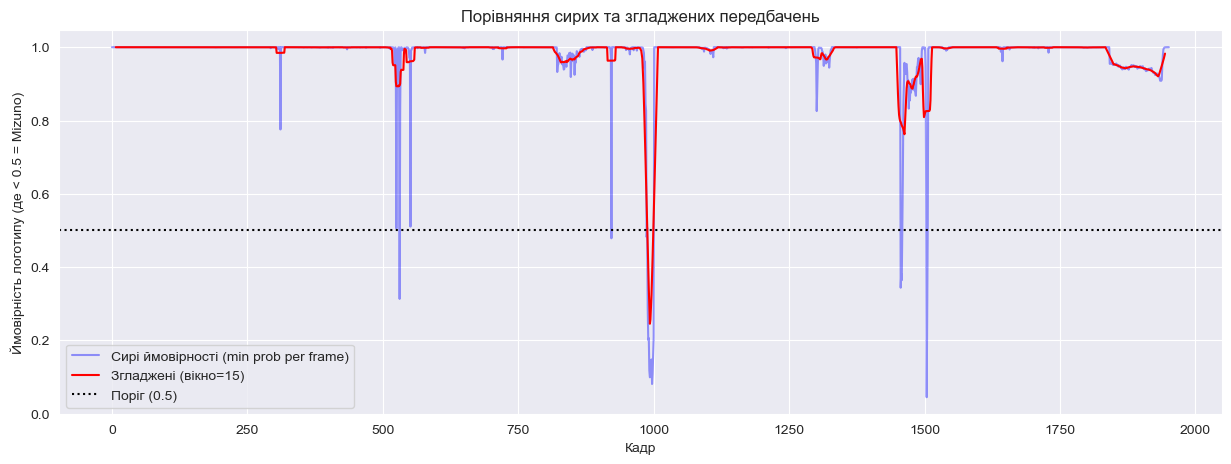

In [25]:
VIDEO_PATH = "dataset_mizuno/Mizuno Running_ Forward We Go.mp4"
# MODEL_PATH = "models/Xception_v1_1.pth"
THRESHOLD = 0.5
WINDOW_SIZE = 299
STRIDE = 150
SMOOTHING_WINDOW = 15
PATCH_BATCH_SIZE = 32

model = load_model(model=model, model_name='Xception_v1_1')
model.eval()

print("Крок 1: Пакетна обробка (Ковзне вікно)")
(frame_indices, frame_probs, fps) = process_video_sliding_window(
    VIDEO_PATH,
    model,
    basic_transform,
    THRESHOLD,
    batch_size_patches=PATCH_BATCH_SIZE)

if frame_indices:
    print("\nКрок 2: Пост-обробка та виведення результатів")
    post_process_and_report_timestamps(
        frame_indices,
        frame_probs,
        fps,
        threshold=THRESHOLD,
        smoothing_window=SMOOTHING_WINDOW)
else:
    print("Обробку відео не вдалося виконати.")